# Part 1: Distributed Data Processing with Spark

## Task 1.1: Spark Environment Setup & Data Loading 

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
.master('local[*]') \
.appName('COMP3610A3') \
.config('spark.sql.adaptive.enabled', 'true') \
.config('spark.driver.memory', '6g') \
.getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/28 02:06:36 WARN Utils: Your hostname, Augusts-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.100.202 instead (on interface en0)
26/03/28 02:06:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/28 02:06:37 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Verify the session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')
print(f'Spark UI: http://localhost:4040')
print(f'Number of executor cores: {spark.sparkContext.defaultParallelism}')
# List available configurations
for key, value in sorted(spark.sparkContext.getConf().getAll()):
    if 'memory' in key.lower() or 'core' in key.lower() or 'master' in key.lower():
        print(f' {key} = {value}')

Spark version: 4.1.1
App name: COMP3610A3
Master: local[*]
Default parallelism: 8
Spark UI: http://localhost:4040
Number of executor cores: 8
 spark.driver.memory = 6g
 spark.master = local[*]


In [3]:
import urllib.request, os
os.makedirs('data', exist_ok=True)
url = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet'
output = 'data/yellow_tripdata_2024-01.parquet'
if not os.path.exists(output):
    print('Downloading NYC Taxi data...')
    urllib.request.urlretrieve(url, output)
    print(f'Downloaded: {os.path.getsize(output) / 1e6:.1f} MB')
else:
    print(f'File already exists: {os.path.getsize(output) / 1e6:.1f} MB')

taxi = spark.read.parquet(output)

File already exists: 50.0 MB


In [4]:
taxi.show(5,True)
taxi.printSchema()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-01-01 00:57:55|  2024-01-01 01:17:43|              1|         1.72|         1|                 N|         186|          79|           2|       17.7|  1.0|    0.5|       0.

In [5]:
print(f'Number of rows: {taxi.count():,}')
print(f'Number of columns: {len(taxi.columns)}')
print(f'Number of partitions: {taxi.rdd.getNumPartitions()}')

Number of rows: 2,964,624
Number of columns: 19
Number of partitions: 8


In [6]:
import time
import pandas as pd

start = time.time()
df_spark = spark.read.parquet('data/yellow_tripdata_2024-01.parquet')
spark_read_time = time.time() - start
# Time Spark action (forces full read)
start = time.time()
spark_count = df_spark.count()

In [7]:
spark_action_time = time.time() - start
# Time Pandas read
start = time.time()
df_pandas = pd.read_parquet('data/yellow_tripdata_2024-01.parquet')
pandas_read_time = time.time() - start
print(f'Spark schema read: {spark_read_time:.3f}s (lazy - no data loaded)')
print(f'Spark count action: {spark_action_time:.3f}s ({spark_count:,} rows)')
print(f'Pandas full read: {pandas_read_time:.3f}s ({len(df_pandas):,} rows)')
print(f'Pandas memory usage: {df_pandas.memory_usage(deep=True).sum() / 1e6:.1f}MB')
# Clean up Pandas DataFrame to free memory
del df_pandas

Spark schema read: 0.049s (lazy - no data loaded)
Spark count action: 0.094s (2,964,624 rows)
Pandas full read: 0.184s (2,964,624 rows)
Pandas memory usage: 418.0MB


## Task 1.2: Data Cleaning & Feature Engineering in Spark

In [8]:
taxi.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [9]:
from pyspark.sql import functions as F

critical_cols =['tpep_pickup_datetime','tpep_dropoff_datetime','trip_distance','PULocationID','DOLocationID','fare_amount','tip_amount','total_amount']

total_rows = taxi.count()

#Remove Null rows
taxi_clean = taxi.dropna(subset=critical_cols)
null_rows = total_rows - taxi_clean.count()

#Filter Out Invalid Trips
taxi_clean = taxi_clean.filter(
    (F.col('trip_distance') > 0) &
    (F.col('fare_amount') > 0) &
    (F.col('fare_amount') <= 500) &
    (F.col('total_amount') > 0) &
    (F.col('tpep_pickup_datetime') < F.col('tpep_dropoff_datetime') )
)

invalid_rows = total_rows - null_rows - taxi_clean.count()

print(total_rows)
print(null_rows)
print(invalid_rows)

2964624
0
95052


In [10]:
taxi_enriched = taxi_clean.withColumns({

'trip_duration_minutes': (F.unix_timestamp('tpep_dropoff_datetime') - F.unix_timestamp('tpep_pickup_datetime')) / 60,

'pickup_hour': F.hour('tpep_pickup_datetime'),

'pickup_day_of_week': F.dayofweek('tpep_pickup_datetime'),

'tip_percentage': F.when(
    F.col('fare_amount') > 0,
    F.col('tip_amount') / F.col('fare_amount') * 100
).otherwise(0),
}).withColumns({
    'trip_speed_mph': F.when(
    F.col('trip_duration_minutes') > 0,
    F.col('trip_distance') / 
    (F.col('trip_duration_minutes') / 60)).otherwise(0),
    })

## Task 1.3: Spark SQL Analytics 


In [11]:
taxi_enriched.createOrReplaceTempView('trips')

#Top 10 busiest pickup locations
busiest_locations = spark.sql('''
    SELECT PULocationID,
    COUNT(*) AS num_trips,
    ROUND(AVG(fare_amount), 2) AS avg_fare,
    ROUND(AVG(trip_distance), 2) AS avg_distance
    FROM trips
    GROUP BY PULocationID
    ORDER BY num_trips DESC
    LIMIT 10
''')
#daty of week with highest average trip speed
high_avg_speed = spark.sql('''
 SELECT 
        date_format(tpep_pickup_datetime, 'EEEE') AS day_name,
        ROUND(AVG(trip_speed_mph), 2) AS avg_speed_mph,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(trip_duration_minutes), 2) AS avg_duration_min
    FROM trips
        GROUP BY date_format(tpep_pickup_datetime, 'EEEE')
        ORDER BY avg_speed_mph DESC
        LIMIT 1

''')

In [12]:
print('Top 10 Busiest Pickup Locations:')
busiest_locations.show()
high_avg_speed.show()

Top 10 Busiest Pickup Locations:
+------------+---------+--------+------------+
|PULocationID|num_trips|avg_fare|avg_distance|
+------------+---------+--------+------------+
|         161|   140141|    15.5|         2.6|
|         237|   140118|   12.38|        1.72|
|         132|   138427|   62.79|       15.93|
|         236|   133962|   12.86|        1.87|
|         162|   104342|   15.07|        2.26|
|         230|   102958|    17.9|        2.97|
|         186|   102152|   16.09|         2.3|
|         142|   101794|   13.62|        2.12|
|         138|    87693|   42.33|        9.71|
|         239|    86466|   13.61|        2.29|
+------------+---------+--------+------------+

+--------+-------------+------------+----------------+
|day_name|avg_speed_mph|avg_distance|avg_duration_min|
+--------+-------------+------------+----------------+
| Tuesday|        17.35|        4.25|           16.17|
+--------+-------------+------------+----------------+



In [13]:
from pyspark.sql.window import Window

# Step 1: Find the top 5 pickup locations overall
top_5_locations = [row.PULocationID for row in 
    taxi_enriched.groupBy('PULocationID')
    .count()
    .orderBy(F.desc('count'))
    .limit(5)
    .collect()]

# Step 2: Get total revenue per location per day (only for top 5)
revenue_by_day = taxi_enriched \
    .filter(F.col('PULocationID').isin(top_5_locations)) \
    .groupBy('pickup_day_of_week', 'PULocationID') \
    .agg(F.sum('total_amount').alias('total_revenue'))

# Step 3: Rank by revenue within each day
day_window = Window.partitionBy('pickup_day_of_week').orderBy(F.desc('total_revenue'))

ranked_revenue = revenue_by_day \
    .withColumn('revenue_rank', F.rank().over(day_window)) \
    .withColumn('day_name', F.when(F.col('pickup_day_of_week') == 1, 'Sunday')
        .when(F.col('pickup_day_of_week') == 2, 'Monday')
        .when(F.col('pickup_day_of_week') == 3, 'Tuesday')
        .when(F.col('pickup_day_of_week') == 4, 'Wednesday')
        .when(F.col('pickup_day_of_week') == 5, 'Thursday')
        .when(F.col('pickup_day_of_week') == 6, 'Friday')
        .when(F.col('pickup_day_of_week') == 7, 'Saturday')) \
    .select('day_name', 'revenue_rank', 'PULocationID', F.round('total_revenue', 2).alias('total_revenue')) \
    .orderBy('pickup_day_of_week', 'revenue_rank')

ranked_revenue.show(35)


+---------+------------+------------+-------------+
| day_name|revenue_rank|PULocationID|total_revenue|
+---------+------------+------------+-------------+
|   Sunday|           1|         132|   1564244.23|
|   Sunday|           2|         161|    249524.25|
|   Sunday|           3|         236|    223270.64|
|   Sunday|           4|         237|    215561.28|
|   Sunday|           5|         162|    188082.18|
|   Monday|           1|         132|   2054604.73|
|   Monday|           2|         161|    460144.28|
|   Monday|           3|         236|    373005.39|
|   Monday|           4|         237|    372575.48|
|   Monday|           5|         162|    334973.93|
|  Tuesday|           1|         132|   1794982.81|
|  Tuesday|           2|         161|     622561.8|
|  Tuesday|           3|         237|    492951.97|
|  Tuesday|           4|         236|    485599.72|
|  Tuesday|           5|         162|    462120.27|
|Wednesday|           1|         132|   1677828.52|
|Wednesday| 

In [14]:
spark.sparkContext.setLogLevel('ERROR')


# Step 1: Count trips per hour
hourly_counts = taxi_enriched.groupBy('pickup_hour') \
    .agg(F.count('*').alias('trip_count'))

# Step 2: Define window — running total from hour 0 to current hour
hour_window = Window.orderBy('pickup_hour') \
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Step 3: Get total trips for percentage calculation
total_trips = taxi_enriched.count()

# Step 4: Add cumulative count and percentage
cumulative = hourly_counts \
    .withColumn('cumulative_count', F.sum('trip_count').over(hour_window)) \
    .withColumn('cumulative_pct', F.round(F.col('cumulative_count') / total_trips * 100, 2)) \
    .orderBy('pickup_hour')

# Show all 24 hours
cumulative.show(24)

# Find the first hour that surpasses 50%
print("Hour that surpasses 50% of daily trips:")
cumulative.filter(F.col('cumulative_pct') >= 50) \
    .select('pickup_hour', 'cumulative_count', 'cumulative_pct') \
    .orderBy('pickup_hour') \
    .show(1)


+-----------+----------+----------------+--------------+
|pickup_hour|trip_count|cumulative_count|cumulative_pct|
+-----------+----------+----------------+--------------+
|          0|     75232|           75232|          2.62|
|          1|     50480|          125712|          4.38|
|          2|     34960|          160672|           5.6|
|          3|     22940|          183612|           6.4|
|          4|     15274|          198886|          6.93|
|          5|     17491|          216377|          7.54|
|          6|     39414|          255791|          8.91|
|          7|     80854|          336645|         11.73|
|          8|    113479|          450124|         15.69|
|          9|    125594|          575718|         20.06|
|         10|    135401|          711119|         24.78|
|         11|    146725|          857844|         29.89|
|         12|    159884|         1017728|         35.47|
|         13|    165326|         1183054|         41.23|
|         14|    178002|       

In [15]:
trip_categories = spark.sql('''
    SELECT
        CASE
            WHEN trip_distance < 2 THEN 'Short (<2 mi)'
            WHEN trip_distance <= 10 THEN 'Medium (2-10 mi)'
            ELSE 'Long (>10 mi)'
        END AS distance_category,
        COUNT(*) AS num_trips,
        ROUND(AVG(fare_amount), 2) AS avg_fare,
        ROUND(AVG(trip_distance), 2) AS avg_distance,
        ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
    FROM trips
    GROUP BY distance_category
    ORDER BY avg_tip_pct DESC
''')
print('Trip Categories by Distance:')
trip_categories.show()
print('Category with highest tip percentage:')
trip_categories.select('distance_category', 'avg_tip_pct') \
    .orderBy(F.desc('avg_tip_pct')) \
    .show(1)


Trip Categories by Distance:
+-----------------+---------+--------+------------+-----------+
|distance_category|num_trips|avg_fare|avg_distance|avg_tip_pct|
+-----------------+---------+--------+------------+-----------+
|    Short (<2 mi)|  1642163|    9.91|        1.13|      23.07|
|    Long (>10 mi)|   225011|   64.67|        21.7|      21.93|
| Medium (2-10 mi)|  1002398|   22.18|        3.96|      18.57|
+-----------------+---------+--------+------------+-----------+

Category with highest tip percentage:
+-----------------+-----------+
|distance_category|avg_tip_pct|
+-----------------+-----------+
|    Short (<2 mi)|      23.07|
+-----------------+-----------+
only showing top 1 row


## Task 1.4: Performance Optimization

In [16]:
import time
from pyspark import StorageLevel

# Define a function that runs multiple queries on the same DataFrame
def multi_query(df):
    q1 = df.groupBy('pickup_hour').agg(F.avg('fare_amount')).count()
    q2 = df.groupBy('PULocationID').agg(F.sum('total_amount')).count()
    q3 = df.filter(F.col('trip_distance') > 10).count()
    return q1 + q2 + q3

# IMPORTANT: Warmup run to eliminate JVM class loading overhead
taxi_enriched.count()

# Baseline: run queries without caching (average of 3 runs)
no_cache_times = []
for i in range(3):
    start = time.time()
    multi_query(taxi_enriched)
    no_cache_times.append(time.time() - start)
no_cache_time = sum(no_cache_times) / len(no_cache_times)
print(f'Without caching: {no_cache_time:.3f}s (avg of 3 runs)')

# Cache the DataFrame
taxi_enriched.cache()

# First run materializes the cache (will be slow - loading data into memory)
start = time.time()
multi_query(taxi_enriched)
cache_first_time = time.time() - start
print(f'First run (materializing cache): {cache_first_time:.3f}s')

# Subsequent runs use the cache (should be noticeably faster)
cache_times = []
for i in range(3):
    start = time.time()
    multi_query(taxi_enriched)
    cache_times.append(time.time() - start)
cache_avg_time = sum(cache_times) / len(cache_times)
print(f'Cached runs: {cache_avg_time:.3f}s (avg of 3 runs)')

print(f'\nSpeedup from caching: {no_cache_time/cache_avg_time:.2f}x')


Without caching: 0.773s (avg of 3 runs)


First run (materializing cache): 2.719s
Cached runs: 0.221s (avg of 3 runs)

Speedup from caching: 3.50x


In [17]:
import os

output_dir = 'output/trips_by_hour'

# Write partitioned by pickup_hour
taxi_enriched.select(
    'tpep_pickup_datetime', 'pickup_hour', 'pickup_day_of_week',
    'PULocationID', 'DOLocationID',
    'trip_distance', 'trip_duration_minutes',
    'fare_amount', 'tip_amount', 'total_amount', 'tip_percentage'
).write \
    .mode('overwrite') \
    .partitionBy('pickup_hour') \
    .parquet(output_dir)

# Inspect the output structure
for item in sorted(os.listdir(output_dir)):
    if item.startswith('pickup_hour'):
        files = os.listdir(os.path.join(output_dir, item))
        parquet_files = [f for f in files if f.endswith('.parquet')]
        print(f'{item}: {len(parquet_files)} file(s)')


pickup_hour=0: 3 file(s)
pickup_hour=1: 3 file(s)
pickup_hour=10: 3 file(s)
pickup_hour=11: 3 file(s)
pickup_hour=12: 3 file(s)
pickup_hour=13: 3 file(s)
pickup_hour=14: 3 file(s)
pickup_hour=15: 3 file(s)
pickup_hour=16: 3 file(s)
pickup_hour=17: 3 file(s)
pickup_hour=18: 3 file(s)
pickup_hour=19: 3 file(s)
pickup_hour=2: 3 file(s)
pickup_hour=20: 3 file(s)
pickup_hour=21: 3 file(s)
pickup_hour=22: 3 file(s)
pickup_hour=23: 3 file(s)
pickup_hour=3: 3 file(s)
pickup_hour=4: 3 file(s)
pickup_hour=5: 3 file(s)
pickup_hour=6: 3 file(s)
pickup_hour=7: 3 file(s)
pickup_hour=8: 3 file(s)
pickup_hour=9: 3 file(s)


In [18]:
ranked_revenue.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [day_name#362, revenue_rank#353, PULocationID#7, total_revenue#363]
   +- Sort [pickup_day_of_week#214 ASC NULLS FIRST, revenue_rank#353 ASC NULLS FIRST], true, 0
      +- Exchange rangepartitioning(pickup_day_of_week#214 ASC NULLS FIRST, revenue_rank#353 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=3207]
         +- Project [CASE WHEN (pickup_day_of_week#214 = 1) THEN Sunday WHEN (pickup_day_of_week#214 = 2) THEN Monday WHEN (pickup_day_of_week#214 = 3) THEN Tuesday WHEN (pickup_day_of_week#214 = 4) THEN Wednesday WHEN (pickup_day_of_week#214 = 5) THEN Thursday WHEN (pickup_day_of_week#214 = 6) THEN Friday WHEN (pickup_day_of_week#214 = 7) THEN Saturday END AS day_name#362, revenue_rank#353, PULocationID#7, round(total_revenue#327, 2) AS total_revenue#363, pickup_day_of_week#214]
            +- Window [rank(total_revenue#327) windowspecdefinition(pickup_day_of_week#214, total_revenue#327 DESC NULLS LAST, specif

# Part 2: RAG Pipeline over Transportation Documents

## Task 2.1: Document Collection & Ingestion

In [19]:
import os
from pypdf import PdfReader

docs_dir = 'docs'

pdf_files = [f for f in os.listdir(docs_dir) if f.endswith('.pdf')]

if not pdf_files:
    print(f"No PDF files found in '{docs_dir}'")
else:
    print(f"Found {len(pdf_files)} PDF file(s)\n")
    for filename in pdf_files:
        filepath = os.path.join(docs_dir, filename)
        reader = PdfReader(filepath)
        print(f"{'='*60}")
        print(f"File: {filename}")
        print(f"Number of pages: {len(reader.pages)}")
        for i, page in enumerate(reader.pages):
            text = page.extract_text()
            print(f"--- Page {i+1} ---")
            print(text[:500])


Found 6 PDF file(s)

File: drivrules.pdf
Number of pages: 62
--- Page 1 ---
* [As reads in the Official Compilation of the Rules of the City of New York.] 
 
 
 
CHAPTER 2 
 
 
 
 
TAXICAB DRIVERS RULES 
 
 
§2-01          Definitions .................................................................................. 4 
§2-02          Requirements for a Taxicab Driver's License to Operate a 
Medallion Taxicab .................................................................... 7 
§2-03          Driver License Applicant Training ....................................... 10 
--- Page 2 ---
 
 
* [As reads in the Official Compilation of the Rules of the City of New York.] 
  
 
§2-29          [Reserved] ................................................................................. 29 
§2-30          Taximeter Condition ............................................................... 29 
§2-31          Tampering with Taximeter, Taximeter Technology System 
and Rooflight Prohibited .........

In [20]:
from langchain_community.document_loaders import PyPDFDirectoryLoader
loader = PyPDFDirectoryLoader("docs/")
raw_documents = loader.load()
print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"First document metadata: {raw_documents[0].metadata}")
print(f"First 200 chars: {raw_documents[0].page_content[:200]}")

/Users/august/Developer/COMP3610_A3/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 268 pages from all PDFs
First document metadata: {'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20100210200748', 'title': 'NEW YORK CITY', 'author': 'City of New York', 'moddate': 'D:20100210200748', 'source': 'docs/drivrules.pdf', 'total_pages': 62, 'page': 0, 'page_label': '1'}
First 200 chars: * [As reads in the Official Compilation of the Rules of the City of New York.] 
 
 
 
CHAPTER 2 
 
 
 
 
TAXICAB DRIVERS RULES 
 
 
§2-01          Definitions .........................................


In [21]:
# Check for empty or very short pages
for doc in raw_documents:
 if len(doc.page_content.strip()) < 50:
  print(f"Short/empty page: {doc.metadata}")
# Check character count distribution
lengths = [len(d.page_content) for d in raw_documents]
print(f"Avg chars per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")

Short/empty page: {'producer': 'Adobe PDF Library 16.0.3', 'creator': 'Adobe InDesign 17.0 (Windows)', 'creationdate': '2021-12-09T15:54:38-05:00', 'author': 'New York City Department of Transportation', 'moddate': '2021-12-10T11:59:36-05:00', 'subject': 'The New York City Streets Plan presents a historic opportunity to think holistically about how we plan for and design for our streets.', 'title': 'NYC Streets Plan', 'trapped': '/False', 'source': 'docs/nyc-streets-plan.pdf', 'total_pages': 96, 'page': 0, 'page_label': '1'}
Short/empty page: {'producer': 'Adobe PDF Library 16.0.3', 'creator': 'Adobe InDesign 17.0 (Windows)', 'creationdate': '2021-12-09T15:54:38-05:00', 'author': 'New York City Department of Transportation', 'moddate': '2021-12-10T11:59:36-05:00', 'subject': 'The New York City Streets Plan presents a historic opportunity to think holistically about how we plan for and design for our streets.', 'title': 'NYC Streets Plan', 'trapped': '/False', 'source': 'docs/nyc-street

In [22]:
# === EXTRACTION REPORT ===
total_pages = len(raw_documents)
total_chars = sum(len(d.page_content) for d in raw_documents)
lengths = [len(d.page_content) for d in raw_documents]

# Quality issues
empty_pages = [d for d in raw_documents if len(d.page_content.strip()) == 0]
short_pages = [d for d in raw_documents if 0 < len(d.page_content.strip()) < 50]
garbled_pages = [d for d in raw_documents if d.page_content.count('�') > 5 
                 or d.page_content.count('\x00') > 5]

print(f"\n{'='*60}")
print(f"EXTRACTION REPORT")
print(f"{'='*60}")
print(f"Total PDF files:       {len(pdf_files)}")
print(f"Total pages extracted: {total_pages}")
print(f"Total character count: {total_chars:,}")
print(f"Avg chars per page:    {total_chars/total_pages:.0f}")
print(f"Min chars on a page:   {min(lengths)}")
print(f"Max chars on a page:   {max(lengths)}")

print(f"\nQUALITY ISSUES:")
print(f"Empty pages (likely scanned images): {len(empty_pages)}")
for d in empty_pages:
    print(f"  - {d.metadata['source']} (page {d.metadata['page'] + 1})")

print(f"Short pages (<50 chars):             {len(short_pages)}")
for d in short_pages:
    print(f"  - {d.metadata['source']} (page {d.metadata['page'] + 1}): '{d.page_content.strip()[:40]}'")

print(f"Garbled text detected:               {len(garbled_pages)}")
for d in garbled_pages:
    print(f"  - {d.metadata['source']} (page {d.metadata['page'] + 1})")

print(f"\nUsable pages: {total_pages - len(empty_pages)} / {total_pages}")



EXTRACTION REPORT
Total PDF files:       6
Total pages extracted: 268
Total character count: 560,593
Avg chars per page:    2092
Min chars on a page:   0
Max chars on a page:   7450

QUALITY ISSUES:
Empty pages (likely scanned images): 11
  - docs/nyc-streets-plan.pdf (page 96)
  - docs/fhv_congestion_study_report.pdf (page 1)
  - docs/fhv_congestion_study_report.pdf (page 6)
  - docs/fhv_congestion_study_report.pdf (page 7)
  - docs/fhv_congestion_study_report.pdf (page 8)
  - docs/fhv_congestion_study_report.pdf (page 13)
  - docs/fhv_congestion_study_report.pdf (page 14)
  - docs/fhv_congestion_study_report.pdf (page 15)
  - docs/fhv_congestion_study_report.pdf (page 17)
  - docs/fhv_congestion_study_report.pdf (page 26)
  - docs/fhv_congestion_study_report.pdf (page 35)
Short pages (<50 chars):             11
  - docs/nyc-streets-plan.pdf (page 1): 'NYCStreetsPlan
December 1, 2021'
  - docs/nyc-streets-plan.pdf (page 2): '2
| NYCStreetsPlan'
  - docs/nyc-streets-plan.pdf (page 5):

## 2.2


In [23]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
 chunk_size=1000, # Target characters per chunk
 chunk_overlap=200, # Overlap between consecutive chunks
 separators=["\n\n", "\n", ". ", " ", ""]
)
chunks = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 268 pages into 777 chunks



=== Chunk 0 ===
Length: 919 chars
Source: {'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20100210200748', 'title': 'NEW YORK CITY', 'author': 'City of New York', 'moddate': 'D:20100210200748', 'source': 'docs/drivrules.pdf', 'total_pages': 62, 'page': 0, 'page_label': '1'}
Preview: * [As reads in the Official Compilation of the Rules of the City of New York.] 
 
 
 
CHAPTER 2 
 
 
 
 
TAXICAB DRIVERS RULES 
 
 
§2-01          Definitions ............................................

=== Chunk 1 ===
Length: 909 chars
Source: {'producer': 'Microsoft® Office Word 2007', 'creator': 'Microsoft® Office Word 2007', 'creationdate': 'D:20100210200748', 'title': 'NEW YORK CITY', 'author': 'City of New York', 'moddate': 'D:20100210200748', 'source': 'docs/drivrules.pdf', 'total_pages': 62, 'page': 0, 'page_label': '1'}
Preview: §2-07          Critical Driver Program ......................................................... 13 
§2-08      

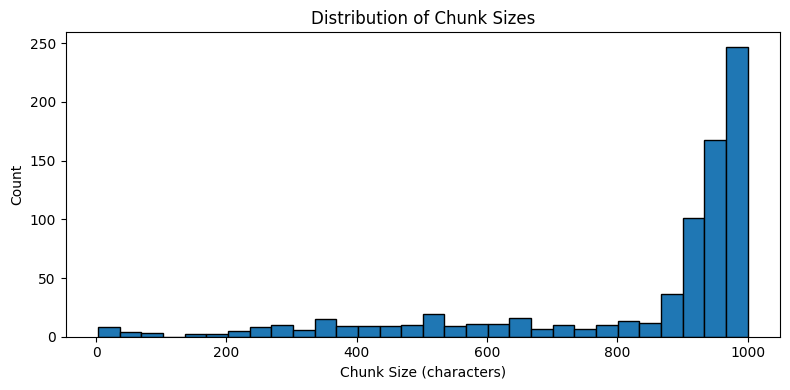

In [24]:
# Inspect a few chunks
for i, chunk in enumerate(chunks[:3]):
 print(f"\n=== Chunk {i} ===")
 print(f"Length: {len(chunk.page_content)} chars")
 print(f"Source: {chunk.metadata}")
 print(f"Preview: {chunk.page_content[:200]}...")
# Visualize chunk size distribution
import matplotlib.pyplot as plt
sizes = [len(c.page_content) for c in chunks]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

In [39]:
# Confirm that adjacent chunks share overlapping text
chunk_a = chunks[0].page_content
chunk_b = chunks[1].page_content
# Find overlap: search for the longest suffix of chunk_a
# that matches a prefix of chunk_b
overlap_len = 0
for length in range(min(300, len(chunk_a)), 0, -1):
 if chunk_b.startswith(chunk_a[-length:]):
    overlap_len = length
    break
 
print(f"Overlap length: {overlap_len} chars")
if overlap_len > 0:
 print(f"Overlap text: {chunk_a[-overlap_len:][:100]}...")
else:
 print("No overlap found (chunks may be from different documents)")

Overlap length: 99 chars
Overlap text: §2-07          Critical Driver Program ......................................................... 13...


26/03/28 04:34:08 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:707)
	at org.apache.spark.storage.BlockManagerMasterE

In [26]:
from langchain_community.embeddings import HuggingFaceEmbeddings
embedding_model = HuggingFaceEmbeddings(
 model_name="all-MiniLM-L6-v2"
)
# Test with a single string
test_embedding = embedding_model.embed_query("What is machine learning?")
print(f"Embedding dimension: {len(test_embedding)}")
print(f"First 5 values: {test_embedding[:5]}")

/var/folders/yd/xx3gc_bd0y911x26fq021tgw0000gn/T/ipykernel_58858/1069574870.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6665.84it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
First 5 values: [-0.01995455101132393, 0.009877984412014484, 0.010249615646898746, 0.02955370582640171, 0.027186445891857147]


In [27]:
import numpy as np
def cosine_similarity(a, b):
 return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
e1 = embedding_model.embed_query("How does a neural network learn?")
e2 = embedding_model.embed_query("What is backpropagation in deep learning?")
e3 = embedding_model.embed_query("What is the capital of France?")
print(f"Similar topics: {cosine_similarity(e1, e2):.4f}")
print(f"Different topics: {cosine_similarity(e1, e3):.4f}")

Similar topics: 0.5958
Different topics: 0.0925


In [28]:
from langchain_community.vectorstores import Chroma
# Create the vector store from chunks
vectorstore = Chroma.from_documents(
 documents=chunks,
 embedding=embedding_model,
 persist_directory="./chroma_db",
 collection_name="3610A3"
)
print(f"Indexed {len(chunks)} chunks in ChromaDB")

Indexed 777 chunks in ChromaDB


In [38]:
chunk_sizes = [500, 1000, 2000]
test_questions = [
    "What are the main conclusions?",
    "What is the congestion pricing policy in NYC?",
    "How do taxi fares affect driver income?",
]
experiment_results = {}

for question in test_questions:
    print(f"\n{'#'*60}")
    print(f"QUERY: {question}")

    for size in chunk_sizes:
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=size, chunk_overlap=int(size * 0.2)
        )
        test_chunks = splitter.split_documents(raw_documents)
        test_store = Chroma.from_documents(
            documents=test_chunks,
            embedding=embedding_model,
            collection_name=f"test_{size}_{hash(question) % 10000}"
        )
        results = test_store.similarity_search_with_score(
            question, k=3
        )
        avg_score = sum(s for _, s in results) / len(results)
        experiment_results[(question, size)] = {"num_chunks": len(test_chunks), "avg_dist": avg_score}
        print(f"\nChunk size: {size} | Num chunks: {len(test_chunks)} "
              f"| Avg distance: {avg_score:.4f}")
        for doc, score in results:
            print(f"  Score {score:.4f}: {doc.page_content[:80]}...")

# Summary
print(f"\n{'='*60}")
print("SUMMARY BY CHUNK SIZE")
for size in chunk_sizes:
    scores = [experiment_results[(q, size)]["avg_dist"] for q in test_questions]
    print(f"  Chunk {size}: overall avg distance = {sum(scores)/len(scores):.4f}")



############################################################
QUERY: What are the main conclusions?

Chunk size: 500 | Num chunks: 1479 | Avg distance: 1.0471
  Score 0.8751: reflected in the Executive Summary and the Conclusion....
  Score 0.8751: reflected in the Executive Summary and the Conclusion....
  Score 1.3912: Appendix Exhibit 1 ................................................................

Chunk size: 1000 | Num chunks: 777 | Avg distance: 1.4037
  Score 1.3912: Appendix Exhibit 1 ................................................................
  Score 1.3912: Appendix Exhibit 1 ................................................................
  Score 1.4286: Methodology .......................................................................

Chunk size: 2000 | Num chunks: 436 | Avg distance: 1.5968
  Score 1.5813: Traffic Safety 
LL 147 instructed TLC and DOT to study a range of aspects of the...
  Score 1.5813: Traffic Safety 
LL 147 instructed TLC and DOT to study a ra

## 2.3


# ???

In [34]:
with open('LOCAL_API_KEY', 'r') as f:
    LLM_API_KEY = f.read().strip()

print(f'API key loaded: {LLM_API_KEY[:4]}...{LLM_API_KEY[-4:]}')

#LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_BASE_URL = "http://127.0.0.1:1234/v1"


API key loaded: sk-l...iPI7


In [35]:
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI

client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
)

try:
    models = client.models.list()
    if models.data:
        print("Available models:")
        for m in models.data:
            print(f"  - {m.id}")
    else:
        print("No models currently loaded in LM Studio.")

    print(f"\nClient configured successfully.")
    print(f"Base URL: {client.base_url}")
except Exception as e:
    print(f"Failed to connect to LM Studio: {e}")
    print(f"Ensure the server is running at {LLM_BASE_URL}")


Available models:
  - mistral-7b-instruct-v0.3
  - qwen/qwen3.5-9b
  - mistralai/mistral-7b-instruct-v0.3
  - zai-org/glm-4.6v-flash
  - text-embedding-nomic-embed-text-v1.5

Client configured successfully.
Base URL: http://127.0.0.1:1234/v1/


In [36]:
response = client.chat.completions.create(
 model="mistral-7b-instruct-v0.3",
 messages=[
 {"role": "user", "content": "What is Big Data Analytics in one sentence?"}
 ],
 max_tokens=1000
)
print(response.choices[0].message.content)
print(f"\nTokens used - Prompt: {response.usage.prompt_tokens}, "
 f"Completion: {response.usage.completion_tokens}, "
 f"Total: {response.usage.total_tokens}")
print(f"Model: {response.model}")
print(f"Finish reason: {response.choices[0].finish_reason}")
print(f"Response ID: {response.id}")


 Big Data Analytics refers to the process of examining, interpreting, and deriving meaningful insights from large, complex datasets using statistical methods, machine learning algorithms, and data visualization tools.

Big Data Analytics involves working with high volumes of structured and unstructured data to identify patterns, trends, and correlations that can be utilized to make informed decisions and drive business growth. By leveraging Big Data Analytics, organizations can gain deeper insights into their customers, operations, and market conditions, enabling them to optimize performance, reduce costs, and improve overall efficiency.

Tokens used - Prompt: 15, Completion: 119, Total: 134
Model: mistral-7b-instruct-v0.3
Finish reason: stop
Response ID: chatcmpl-4yyhqaa45ol4tpt15qdkut


In [37]:
# Stop the SparkSession to release all resources
# This shuts down the Spark driver and all executors
# spark.stop()
# print('SparkSession stopped. All resources released.')
